**Sentiment Analysis on Movie Reviews**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading the Dataset

In [4]:
import pandas as pd
import numpy as np

raw_reviews_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CS-171/IMDB Dataset.csv")
raw_reviews_df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Exploratory Data Analysis

  sentiment  count
0  positive  25000
1  negative  25000


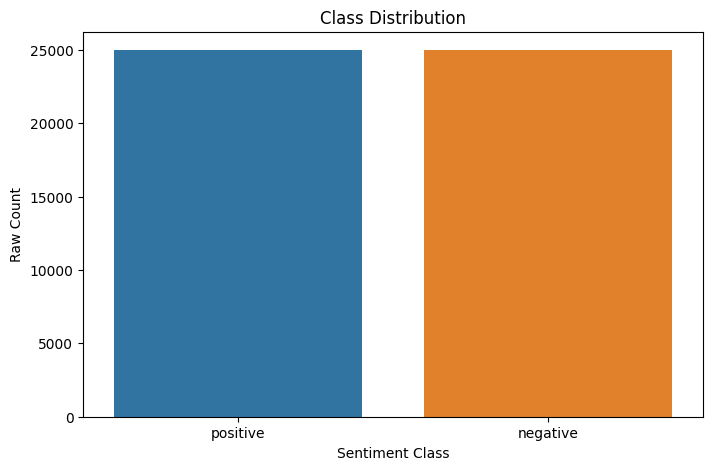

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Class Distributions
class_distributions = raw_reviews_df['sentiment'].value_counts().reset_index()
print(class_distributions)

plt.figure(figsize=(8, 5))
sns.barplot(data=class_distributions,
            x='sentiment',
            y='count',
            hue='sentiment')

plt.title("Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Raw Count")
plt.show()

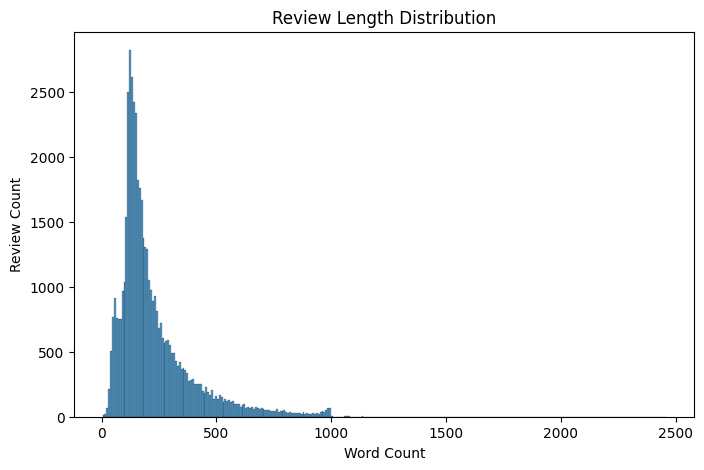

In [6]:
# Sequence Length

# The replace function was added to deal with the line break tags seen in the data preview above
sequence_word_length = raw_reviews_df['review'].str.replace('<br />', ' ', regex=False).str.split().str.len()

plt.figure(figsize=(8, 5))
sns.histplot(sequence_word_length)

plt.title("Review Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Review Count")
plt.show()

Data Preprocessing

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Basic Cleaning (removing <br /> tags again)
raw_reviews_df['cleaned_review'] = raw_reviews_df['review'].str.replace('<br />', ' ', regex=False)

# Split into Train and Test sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    raw_reviews_df['cleaned_review'],
    raw_reviews_df['sentiment'].map({'positive': 1, 'negative': 0}),
    test_size=0.2,
    random_state=42
)

# Keras Tokenization
unique_words_count = len(set(raw_reviews_df['cleaned_review'].str.lower().str.split().explode()))
print(f"Total unique words in dataset: {unique_words_count}")
VOCAB_SIZE = 10000

# We want to preseverve most our data, so our max_len is based on percentile
percentile_90 = sequence_word_length.quantile(0.90)
print(f"The 90th percentile of review lengths is: {percentile_90} words.")
# Ensure MAX_LEN is an integer
MAX_LEN = int(percentile_90)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

# Transform and Pad
X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_raw), maxlen=MAX_LEN, padding='post')
X_test = pad_sequences(tokenizer.texts_to_sequences(X_test_raw), maxlen=MAX_LEN, padding='post')

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Total unique words in dataset: 365437
The 90th percentile of review lengths is: 447.0 words.
Train shape: (40000, 447)
Test shape: (10000, 447)
